In [1]:
import pandas as pd

df = pd.read_csv("dataset/breast-cancer.csv")

print(df.head())
print(df.shape)

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  texture_worst  perimeter_worst  area_wor

In [2]:
# Features and target
X = df.drop(columns=["id", "diagnosis"])
y = df["diagnosis"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2, 
    random_state=42,
    stratify=y
)

In [4]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

# Train the model
nb.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[285.,170.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.63,0.37]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[<U1](2,)","['B','M']"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,0.0003384
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](30,)","['radius_mean','texture_mean','perimeter_mean',...,'concave points_worst', 'symmetry_worst','fractal_dimension_worst']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,30
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 30)","[[ 12.16, 18.05, 78.1 ,..., 0.07, 0.27, 0.08], [ 17.54, 21.71,115.87,..., 0.18, 0.33, 0.09]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 30)","[[ 3.17, 15.49,139.65,..., 0. , 0. , 0. ], [ 10.76, 14.79,503.93,..., 0. , 0.01, 0. ]]"


In [5]:
# Make predictions
y_pred = nb.predict(X_test)

In [6]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy:", accuracy * 100, "%")

Accuracy: 0.9385964912280702
Accuracy: 93.85964912280701 %


In [7]:

results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

correct_predictions = results[
    results["Actual"] == results["Predicted"]
]

wrong_predictions = results[
    results["Actual"] != results["Predicted"]
]

print("Correct predictions:")
print(correct_predictions)

print("\nWrong predictions:")
if len(wrong_predictions) == 0:
    print("No wrong predictions!")
else:
    print(wrong_predictions)

Correct predictions:
    Actual Predicted
0        B         B
1        M         M
2        B         B
4        B         B
5        B         B
..     ...       ...
108      M         M
109      B         B
110      B         B
111      B         B
113      M         M

[107 rows x 2 columns]

Wrong predictions:
    Actual Predicted
3        M         B
6        M         B
16       M         B
24       M         B
27       M         B
42       M         B
112      M         B


Confusion Matrix:
[[72  0]
 [ 7 35]]


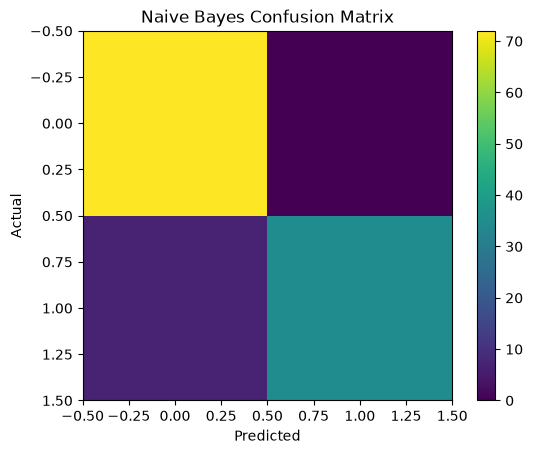

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

plt.imshow(cm)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Naive Bayes Confusion Matrix")
plt.colorbar()
plt.show()

In [9]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=nb.classes_
))

Classification Report:
              precision    recall  f1-score   support

           B       0.91      1.00      0.95        72
           M       1.00      0.83      0.91        42

    accuracy                           0.94       114
   macro avg       0.96      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114

